# Denoising Diffusion Probabilistic Models (DDPM) for MNIST Generation

## Overview
This notebook implements a **Denoising Diffusion Probabilistic Model (DDPM)** from scratch to generate MNIST digits.

### Key Concepts:
1. **Forward Process (q)**: Gradually adds Gaussian noise to an image over T timesteps until it becomes pure noise
2. **Reverse Process (p)**: A learned U-Net model that predicts the noise at each step, allowing us to denoise from pure noise back to a clean image
3. **Training Objective**: Train the U-Net to predict the noise that was added at each timestep

### Theory Behind DDPMs:
- **Forward diffusion**: $q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$
- **The magic**: We can jump directly to any timestep $t$ using: $q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1-\bar{\alpha}_t)I)$
- **Training**: Learn to predict noise $\epsilon$ at any timestep $t$
- **Sampling**: Start from noise and iteratively denoise using the reverse process

In [1]:
# =====================================================
# IMPORTS: All necessary libraries for DDPM implementation
# =====================================================

import os  # For file/directory operations
import torch  # PyTorch core library for tensor operations and neural networks
import torch.nn as nn  # Neural network modules (Conv2d, Linear, etc.)
import torch.nn.functional as F  # Functional API (interpolate, etc.)
import numpy as np  # For numerical operations (used in time embeddings)
from torch.utils.data import DataLoader  # For batching and loading datasets
from torchvision import datasets, transforms  # MNIST dataset and image transformations
import matplotlib.pyplot as plt  # For visualization of generated images

## 1. Configuration & Hyperparameters

### Device Selection
- Use GPU (CUDA) if available for faster training, otherwise fall back to CPU

### Key Hyperparameters:
- **T (Timesteps)**: Total number of diffusion steps (300). More steps = smoother noise schedule but slower sampling
- **BATCH_SIZE**: Number of images processed together (128). Larger = more stable gradients but more memory
- **LR (Learning Rate)**: Step size for optimizer (2e-4). Controls how fast the model learns
- **EPOCHS**: Number of complete passes through the dataset (15)

In [2]:
# =====================================================
# CONFIGURATION: Set up device and hyperparameters
# =====================================================

# Device Selection: Use CUDA (GPU) if available, otherwise CPU
# GPU accelerates tensor operations significantly (10-100x faster for deep learning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# T: Total number of diffusion timesteps in the forward process
# At t=0: clean image, At t=T: pure Gaussian noise
# Theory: More timesteps = smoother/gradual noise addition but slower sampling
T = 300

# BATCH_SIZE: Number of images to process simultaneously
# Larger batches = more stable gradient estimates but require more GPU memory
# 128 is a good balance for MNIST on most GPUs
BATCH_SIZE = 128

# LR: Learning rate for Adam optimizer
# Controls the step size when updating model weights
# 2e-4 (0.0002) is a common choice for diffusion models
LR = 2e-4

# EPOCHS: Number of complete passes through the training dataset
# 15 epochs is usually sufficient for MNIST to learn the distribution
EPOCHS = 15

print(f"Using device: {device}")
print(f"Configuration: T={T}, Batch={BATCH_SIZE}, LR={LR}, Epochs={EPOCHS}")

Using device: cuda
Configuration: T=300, Batch=128, LR=0.0002, Epochs=15


## 2. Noise Scheduler - The Mathematical Foundation

### Forward Diffusion Process Theory:

The forward process gradually adds Gaussian noise to an image over T steps:
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}x_{t-1}, \beta_t I)$$

**Key Variables:**
- $\beta_t$ : Variance schedule (how much noise to add at step t)
- $\alpha_t = 1 - \beta_t$ : How much signal to retain
- $\bar{\alpha}_t = \prod_{i=1}^{t} \alpha_i$ : Cumulative product (total signal remaining after t steps)

### The Magic Formula:
Instead of applying noise T times sequentially, we can **jump directly** to any timestep $t$:
$$x_t = \sqrt{\bar{\alpha}_t} \cdot x_0 + \sqrt{1-\bar{\alpha}_t} \cdot \epsilon$$

where $\epsilon \sim \mathcal{N}(0, I)$ is standard Gaussian noise.

**Why this matters**: During training, we can randomly sample any timestep $t$ and corrupt the image in one step!

### Implementation Strategy:
1. Define linear variance schedule: $\beta_t$ from 0.0001 to 0.02
2. Precompute all $\alpha_t$ and $\bar{\alpha}_t$ values
3. Store $\sqrt{\bar{\alpha}_t}$ and $\sqrt{1-\bar{\alpha}_t}$ for efficient sampling

In [3]:
# =====================================================
# NOISE SCHEDULER: Precompute all diffusion constants
# =====================================================

# beta_t: Variance schedule - defines how much noise to add at each timestep
# Linear schedule from 0.0001 to 0.02 means:
# - Early steps (t=0): Add very little noise (beta=0.0001)
# - Later steps (t=T): Add more noise (beta=0.02)
# Theory: Linear schedule is simple and works well for images
betas = torch.linspace(0.0001, 0.02, T).to(device)  # Shape: [T]

# alpha_t = 1 - beta_t: How much of the original signal to retain at each step
# If beta_t=0.01, then alpha_t=0.99 (keep 99% of signal, add 1% noise)
alphas = 1. - betas  # Shape: [T]

# alpha_bar_t (alpha_bar): Cumulative product of all alpha values up to timestep t
# This represents the total amount of original signal remaining after t steps
# Example: If alpha_1=0.99, alpha_2=0.98, then alpha_bar_2 = 0.99 x 0.98 = 0.9702
# Theory: alpha_bar_t allows us to jump directly to any timestep without iterating
alphas_cumprod = torch.cumprod(alphas, axis=0)  # Shape: [T]

# Precompute square roots for the closed-form diffusion equation:
# x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
# Storing these avoids repeated sqrt operations during training
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)  # Coefficient for clean image
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)  # Coefficient for noise

def forward_diffusion_sample(x_0, t):
    """
    Apply forward diffusion: corrupt clean image x_0 by adding noise at timestep t.

    Theory: Instead of iteratively adding noise t times, we use the closed form:
        q(x_t | x_0) = N(x_t; sqrt(alpha_bar_t)*x_0, (1-alpha_bar_t)*I)

    Parameters:
        x_0: Clean input images, shape [B, C, H, W] (B=batch, C=channels, H/W=height/width)
        t: Timestep indices, shape [B], values in range [0, T-1]

    Returns:
        x_t: Noisy images at timestep t, shape [B, C, H, W]
        noise: The actual noise that was added (needed as training target), shape [B, C, H, W]

    Implementation:
        1. Sample random Gaussian noise epsilon ~ N(0, I)
        2. Extract sqrt(alpha_bar_t) and sqrt(1-alpha_bar_t) for the specific timesteps in batch
        3. Apply formula: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*epsilon
    """
    # Sample standard Gaussian noise with same shape as input image
    # randn_like ensures same device (CPU/GPU) and dtype as x_0
    noise = torch.randn_like(x_0)  # epsilon ~ N(0, I), shape: [B, C, H, W]

    # Extract the precomputed constants for each timestep in the batch
    # t is shape [B], we index into our precomputed arrays
    # view(-1, 1, 1, 1) reshapes from [B] to [B, 1, 1, 1] for broadcasting
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)  # Shape: [B, 1, 1, 1]
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)  # Shape: [B, 1, 1, 1]

    # Apply the closed-form diffusion equation
    # This is the "magic" of DDPM - we can jump to ANY timestep in one operation!
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
    # The view operation broadcasts [B,1,1,1] across [B,C,H,W]
    x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

    # Return both the corrupted image and the noise
    # We need the noise because that's what we'll train the U-Net to predict!
    return x_t, noise

print("Noise scheduler initialized with linear beta schedule")
print(f"  beta range: {betas[0].item():.6f} -> {betas[-1].item():.6f}")
print(f"  alpha_bar range: {alphas_cumprod[0].item():.6f} -> {alphas_cumprod[-1].item():.6f}")

Noise scheduler initialized with linear beta schedule
  beta range: 0.000100 -> 0.020000
  alpha_bar range: 0.999900 -> 0.048058


## 3. Time Embeddings - Teaching the Network About Timesteps

### Problem:
The U-Net needs to know **which timestep** we're at to denoise correctly. The model should behave differently at t=10 (mostly clean) vs t=290 (mostly noise).

### Solution: Sinusoidal Position Embeddings
Borrowed from the Transformer architecture (Attention is All You Need), we convert the integer timestep into a high-dimensional vector using sine and cosine functions.

**Formula:**
$$\text{PE}(t, 2i) = \sin(t / 10000^{2i/d})$$
$$\text{PE}(t, 2i+1) = \cos(t / 10000^{2i/d})$$

### Why Sinusoidal?
1. **Unique representation**: Each timestep gets a unique pattern
2. **Smooth transitions**: Similar timesteps have similar embeddings
3. **Learnable relationships**: The network can learn to interpret these patterns
4. **No additional training**: These are deterministic, not learned

### Architecture Flow:
1. Timestep $t$ (integer) -> Sinusoidal embedding (256-dim vector)
2. Pass through MLP -> Time features
3. Inject into each ResBlock -> Condition denoising on timestep

In [4]:
# =====================================================
# TIME EMBEDDINGS: Convert timestep integers into continuous vectors
# =====================================================

class SinusoidalPositionEmbeddings(nn.Module):
    """
    Converts discrete timestep values (0 to T-1) into continuous vector representations.

    Theory: Uses sinusoidal functions at different frequencies (like Transformer positional encodings)
    to create unique, smooth embeddings for each timestep.

    Architecture:
        Input: Integer timestep t, shape [B] (batch of timestep indices)
        Output: Embedding vector, shape [B, dim] where dim is embedding dimension

    Why sinusoid al?
        - Each timestep gets a unique pattern of sine/cosine values
        - Similar timesteps have similar embeddings (smooth interpolation)
        - The network can learn temporal relationships
    """

    def __init__(self, dim):
        """
        Initialize the embedding layer.

        Parameters:
            dim: Dimension of the output embedding (typically 256 or 512)
                 This should be even (half for sin, half for cos)
        """
        super().__init__()
        self.dim = dim  # Store embedding dimension

    def forward(self, time):
        """
        Convert timesteps to sinusoidal embeddings.

        Parameters:
            time: Tensor of timestep indices, shape [B]
                  Values range from 0 to T-1 (e.g., 0 to 299 for T=300)

        Returns:
            embeddings: Sinusoidal position embeddings, shape [B, dim]

        Implementation details:
            1. Create frequencies that decrease exponentially (10000^(-2i/dim))
            2. For each frequency, compute sin and cos of (time * frequency)
            3. Concatenate all sine and cosine values
        """
        device = time.device  # Ensure embeddings are on the same device as input
        half_dim = self.dim // 2  # Split dimension: half for sin, half for cos

        # Create exponentially decreasing frequencies
        # Formula: 10000^(-2i/dim) for i in [0, half_dim)
        # This gives us frequencies from 1 to 1/10000
        embeddings = np.log(10000) / (half_dim - 1)  # Constant: ln(10000)/(half_dim-1)

        # Create frequency multipliers: exp(-i * ln(10000)/(half_dim-1))
        # This evaluates to: [1, 10000^(-2/dim), 10000^(-4/dim), ..., 10000^(-1)]
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        # Shape: [half_dim]

        # Multiply each timestep by each frequency
        # time[:, None] reshapes [B] to [B, 1] for broadcasting
        # embeddings[None, :] reshapes [half_dim] to [1, half_dim]
        # Result: outer product gives all combinations
        embeddings = time[:, None] * embeddings[None, :]  # Shape: [B, half_dim]

        # Apply sine to first half, cosine to second half, then concatenate
        # This creates unique patterns: [sin(f1*t), sin(f2*t), ..., cos(f1*t), cos(f2*t), ...]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        # Shape: [B, dim] where dim = 2 * half_dim

        return embeddings

print("Sinusoidal time embedding initialized")
print(f"  Embedding dimension: 256")
print(f"  Timesteps range: 0 to {T-1}")

Sinusoidal time embedding initialized
  Embedding dimension: 256
  Timesteps range: 0 to 299


## 4. Residual Block with Time Conditioning

### Residual Connections (ResNet):
$$y = F(x) + x$$
- Allows gradients to flow directly through the network
- Helps train very deep networks by avoiding vanishing gradients
- Learn residual/difference rather than direct mapping

### Time Conditioning:
The key innovation in diffusion models is **conditioning every layer on the timestep**:
1. Extract time embedding: $t_{emb} \in \mathbb{R}^{256}$
2. Project to channel dimension: $t_{feat} = \text{Linear}(t_{emb}) \in \mathbb{R}^{C}$
3. Add to feature maps: $h = h + t_{feat}$ (broadcast across spatial dimensions)

**Why?** The same U-Net must denoise images at all timesteps. Time conditioning tells each layer "you're looking at timestep t" so it can adjust its behavior accordingly.

### Architecture:
```
Input (B, C_in, H, W) + Time (B, 256)
    |
    v
Conv3x3 -> InstanceNorm -> LeakyReLU
    |
    v
+ Time Injection (broadcast to HxW)
    |
    v
Conv3x3 -> InstanceNorm
    |
    v
+ Residual Connection
    |
    v
LeakyReLU -> Output (B, C_out, H, W)
```

In [5]:
# =====================================================
# RESIDUAL BLOCK: Building block of the U-Net with time conditioning
# =====================================================

class ResidualBlock(nn.Module):
    """
    A residual block with time conditioning - the core building block of our diffusion U-Net.

    Theory:
        - Residual connection: Output = F(input) + input (helps gradient flow)
        - Time conditioning: Injects timestep information into feature processing
        - The network learns a residual (difference) rather than direct mapping

    Architecture:
        1. Conv -> Norm -> Activation
        2. Time injection (linear projection + addition)
        3. Conv -> Norm
        4. Add skip connection (residual)
        5. Final activation

    Key innovation: Time embeddings are injected BETWEEN the two convolutions,
    allowing the block to adjust its processing based on the current timestep.
    """

    def __init__(self, in_c, out_c, time_emb_dim):
        """
        Initialize the residual block.

        Parameters:
            in_c: Number of input channels (e.g., 32, 64, 128)
            out_c: Number of output channels (can be different from in_c)
            time_emb_dim: Dimension of time embedding vector (typically 256)
        """
        super().__init__()

        # First convolutional layer
        # Conv2d parameters: (in_channels, out_channels, kernel_size, stride, padding)
        # kernel_size=3, stride=1, padding=1 keeps spatial dimensions unchanged
        self.conv1 = nn.Conv2d(in_c, out_c, 3, 1, 1)

        # Instance Normalization: Normalizes each channel independently for each sample
        # Better than BatchNorm for generative models (doesn't depend on batch statistics)
        self.bn1 = nn.InstanceNorm2d(out_c)

        # Second convolutional layer (same configuration)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1)
        self.bn2 = nn.InstanceNorm2d(out_c)

        # LeakyReLU activation: f(x) = x if x > 0, else 0.01*x
        # The small negative slope (0.01) helps gradient flow for negative values
        # inplace=True saves memory by modifying the input directly
        self.relu = nn.LeakyReLU(0.01, inplace=True)

        # TIME CONDITIONING: Project time embedding to match output channels
        # Linear layer transforms time_emb_dim (256) -> out_c (32/64/128/etc.)
        # This allows time information to be added to the features
        self.time_mlp = nn.Linear(time_emb_dim, out_c)

        # Shortcut connection for residual learning
        # If input and output channels differ, we need a projection
        # Otherwise, use identity (empty Sequential)
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            # Project input to match output channels using 1x1 convolution
            # 1x1 conv changes channels but preserves spatial dimensions
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=1),
                nn.InstanceNorm2d(out_c)
            )

    def forward(self, x, t_emb):
        """
        Forward pass through the residual block with time conditioning.

        Parameters:
            x: Input feature map, shape [B, in_c, H, W]
            t_emb: Time embedding vector, shape [B, time_emb_dim]

        Returns:
            Output feature map, shape [B, out_c, H, W]

        Flow:
            1. Conv -> Norm -> ReLU
            2. Add time features (conditioning on timestep)
            3. Conv -> Norm
            4. Add residual connection
            5. Final ReLU
        """

        # First convolution block: Conv -> InstanceNorm -> LeakyReLU
        h = self.relu(self.bn1(self.conv1(x)))
        # h shape: [B, out_c, H, W]

        # === TIME INJECTION: This is where we condition on the timestep ===
        # 1. Project time embedding from time_emb_dim to out_c dimensions
        time_feat = self.relu(self.time_mlp(t_emb))
        # time_feat shape: [B, out_c]

        # 2. Reshape and broadcast time features to spatial dimensions
        # Original: [B, out_c] -> Target: [B, out_c, H, W]
        # The trick: (...,) + (None,) * 2 adds two dimensions at the end
        # This reshapes [B, out_c] to [B, out_c, 1, 1]
        # Broadcasting then expands this to [B, out_c, H, W]
        time_feat_reshaped = time_feat[(...,) + (None,) * 2]
        # Equivalent to: time_feat.view(B, out_c, 1, 1).expand(-1, -1, H, W)

        # 3. Add time information to features
        # This conditions the features on which timestep we're denoising
        # The network learns to use this information to adjust its behavior
        h = h + time_feat_reshaped
        # h shape: [B, out_c, H, W] (time information now embedded in features)

        # Second convolution block: Conv -> InstanceNorm (no ReLU yet)
        h = self.bn2(self.conv2(h))
        # h shape: [B, out_c, H, W]

        # === RESIDUAL CONNECTION ===
        # Add the input (possibly projected) to the processed features
        # This is the "residual learning" that makes deep networks trainable
        # Theory: Learn F(x) such that output = F(x) + x
        # If input/output channels differ, shortcut does a 1x1 conv projection
        output = self.relu(h + self.shortcut(x))
        # output shape: [B, out_c, H, W]

        return output

print("Residual Block with time conditioning defined")
print("  Features: 2 convs, instance norm, skip connection, time injection")

Residual Block with time conditioning defined
  Features: 2 convs, instance norm, skip connection, time injection


## 5. Diffusion U-Net Architecture

### U-Net Overview:
U-Net is a symmetric encoder-decoder architecture with skip connections, originally designed for image segmentation, now adapted for diffusion models.

### Architecture Components:

**Encoder (Downsampling Path):**
- Captures hierarchical features at multiple scales
- Each level: ResBlock -> MaxPool (reduce spatial dimensions by 2x)
- Channels increase: 1 -> 32 -> 64 -> 128 (more features, less spatial info)

**Bottleneck:**
- Processes the most compressed representation (3x3x256)
- Contains high-level semantic information

**Decoder (Upsampling Path):**
- Reconstructs spatial dimensions while reducing channels
- Each level: Upsample (x2) -> Concatenate with encoder features -> ResBlock
- Skip connections preserve fine details from encoder

### Skip Connections (Key Innovation):
Direct connections from encoder to decoder at same resolution:
```
Encoder 28x28 -------> Decoder 28x28
Encoder 14x14 -----> Decoder 14x14
Encoder 7x7 ---> Decoder 7x7
```
**Why?** Helps preserve spatial details lost during downsampling.

### Time Conditioning:
Every ResBlock receives the time embedding, making the entire network timestep-aware.

### Input/Output:
- Input: Noisy image $x_t$ at timestep $t$
- Output: Predicted noise $\hat{\epsilon}$ that was added

In [6]:
# =====================================================
# DIFFUSION U-NET: The main noise prediction network
# =====================================================

class DiffusionUNet(nn.Module):
    """
    A U-Net architecture adapted for diffusion models with time conditioning.

    Purpose: Predict the noise epsilon that was added to an image at timestep t

    Theory:
        - Takes as input: noisy image x_t and timestep t
        - Outputs: predicted noise epsilon_hat (same shape as input)
        - Training objective: minimize MSE between predicted and actual noise

    Architecture:
        Encoder: 28x28 -> 14x14 -> 7x7 -> 3x3 (spatial compression, channel expansion)
        Bottleneck: 3x3 at 256 channels (most compressed representation)
        Decoder: 3x3 -> 7x7 -> 14x14 -> 28x28 (spatial expansion, channel reduction)
        Skip connections: Concatenate encoder features to decoder at each level

    Time conditioning: Every ResBlock receives time embedding to adjust behavior per timestep
    """

    def __init__(self):
        """
        Initialize the diffusion U-Net with encoder, bottleneck, and decoder.
        """
        super().__init__()

        # Time embedding dimension (size of timestep representation)
        time_dim = 256  # Higher = more expressive but more parameters

        # === TIME EMBEDDING NETWORK ===
        # Converts integer timestep t into a continuous vector
        # Flow: t (int) -> Sinusoidal(256-d) -> Linear(256->256) -> LeakyReLU
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),  # Project t to 256-d sinusoidal embedding
            nn.Linear(time_dim, time_dim),  # Learn non-linear transformation of time
            nn.LeakyReLU(0.01, inplace=True)  # Non-linearity
        )
        # Output: time embedding vector of dimension time_dim for each sample in batch

        # === ENCODER (Downsampling Path) ===
        # Progressive spatial compression with channel expansion
        # Each encoder level: processes features at a specific resolution

        # Encoder Level 1: 1 channel (grayscale) -> 32 channels at 28x28
        # Input: [B, 1, 28, 28], Output: [B, 32, 28, 28]
        self.enc1 = ResidualBlock(1, 32, time_dim)

        # Encoder Level 2: 32 -> 64 channels at 14x14 (after pooling)
        # Input: [B, 32, 14, 14], Output: [B, 64, 14, 14]
        self.enc2 = ResidualBlock(32, 64, time_dim)

        # Encoder Level 3: 64 -> 128 channels at 7x7 (after pooling)
        # Input: [B, 64, 7, 7], Output: [B, 128, 7, 7]
        self.enc3 = ResidualBlock(64, 128, time_dim)

        # === BOTTLENECK ===
        # Processes the most compressed representation
        # 128 -> 256 channels at ~3x3 (after pooling)
        # This captures the highest-level semantic information
        # Input: [B, 128, 3, 3], Output: [B, 256, 3, 3]
        self.b = ResidualBlock(128, 256, time_dim)

        # === DECODER (Upsampling Path) ===
        # Progressive spatial expansion with channel reduction
        # Each level concatenates encoder features (skip connections) before processing

        # Upsampling layers: bilinear interpolation to 2x spatial dimensions
        # mode='bilinear': smooth interpolation (better for images than nearest-neighbor)
        # align_corners=True: aligns corner pixels between input/output (important for precise upsampling)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Decoder Level 1: (256 + 128) -> 128 channels at 7x7
        # Input: [B, 384, 7, 7] (256 from bottleneck + 128 from enc3), Output: [B, 128, 7, 7]
        # The +128 is from concatenating enc3 features (skip connection)
        self.d1 = ResidualBlock(256 + 128, 128, time_dim)

        # Decoder Level 2: (128 + 64) -> 64 channels at 14x14
        # Input: [B, 192, 14, 14] (128 from d1 + 64 from enc2), Output: [B, 64, 14, 14]
        self.d2 = ResidualBlock(128 + 64, 64, time_dim)

        # Decoder Level 3: (64 + 32) -> 32 channels at 28x28
        # Input: [B, 96, 28, 28] (64 from d2 + 32 from enc1), Output: [B, 32, 28, 28]
        self.d3 = ResidualBlock(64 + 32, 32, time_dim)

        # === OUTPUT LAYER ===
        # Final 1x1 convolution to produce predicted noise
        # 32 channels -> 1 channel (grayscale noise prediction)
        # kernel_size=1: pointwise convolution, just combines channels
        # Output: [B, 1, 28, 28] (predicted noise with same shape as input image)
        self.output = nn.Conv2d(32, 1, kernel_size=1)

        # === POOLING LAYER ===
        # MaxPool2d: takes maximum value in each 2x2 window
        # Reduces spatial dimensions by 2x (H/2, W/2)
        # Used in encoder to progressively compress spatial information
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x, t):
        """
        Forward pass: predict noise in the input image at timestep t.

        Parameters:
            x: Noisy input image, shape [B, 1, 28, 28]
               This is x_t from the diffusion process
            t: Timestep indices, shape [B]
               Integer values from 0 to T-1 indicating noise level

        Returns:
            Predicted noise epsilon_hat, shape [B, 1, 28, 28]
            This should match the actual noise that was added to create x_t

        Flow:
            1. Convert timestep t to embedding
            2. Encoder: downsample and extract features at multiple scales
            3. Bottleneck: process compressed representation
            4. Decoder: upsample and combine with encoder features (skip connections)
            5. Output: predicted noise
        """

        # === TIME EMBEDDING ===
        # Convert integer timesteps to continuous vectors
        # t shape: [B] -> t_emb shape: [B, 256]
        t_emb = self.time_mlp(t)
        # This embedding will be passed to every ResBlock to condition on timestep

        # === ENCODER PATH ===
        # Progressively downsample while increasing channels
        # Save encoder outputs for skip connections to decoder

        # Level 1: Process at original resolution (28x28)
        x1 = self.enc1(x, t_emb)  # [B, 1, 28, 28] -> [B, 32, 28, 28]

        # Level 2: Pool then process (14x14)
        x2 = self.enc2(self.pool(x1), t_emb)  # [B, 32, 14, 14] -> [B, 64, 14, 14]

        # Level 3: Pool then process (7x7)
        x3 = self.enc3(self.pool(x2), t_emb)  # [B, 64, 7, 7] -> [B, 128, 7, 7]

        # === BOTTLENECK ===
        # Process the most compressed representation (~3x3)
        b = self.b(self.pool(x3), t_emb)  # [B, 128, 3, 3] -> [B, 256, 3, 3]
        # At this point, spatial information is highly compressed
        # but we have rich semantic features (256 channels)

        # === DECODER PATH ===
        # Progressively upsample while decreasing channels
        # Use skip connections to preserve spatial details from encoder

        # Level 1: Upsample bottleneck and concatenate with enc3
        u1 = self.up1(b)  # [B, 256, 3, 3] -> [B, 256, 6, 6]
        # Fix size mismatch due to MNIST's 28x28 dimensions
        # Interpolate to exactly match x3's spatial dimensions
        u1 = F.interpolate(u1, size=x3.shape[-2:], mode='bilinear')  # [B, 256, 7, 7]
        # Concatenate upsampled features with encoder features (skip connection)
        d1 = self.d1(torch.cat([u1, x3], dim=1), t_emb)  # [B, 384, 7, 7] -> [B, 128, 7, 7]
        # dim=1: concatenate along channel dimension

        # Level 2: Upsample and concatenate with enc2
        u2 = self.up2(d1)  # [B, 128, 7, 7] -> [B, 128, 14, 14]
        u2 = F.interpolate(u2, size=x2.shape[-2:], mode='bilinear')  # Ensure exact match
        d2 = self.d2(torch.cat([u2, x2], dim=1), t_emb)  # [B, 192, 14, 14] -> [B, 64, 14, 14]

        # Level 3: Upsample and concatenate with enc1
        u3 = self.up3(d2)  # [B, 64, 14, 14] -> [B, 64, 28, 28]
        u3 = F.interpolate(u3, size=x1.shape[-2:], mode='bilinear')  # Ensure exact match
        d3 = self.d3(torch.cat([u3, x1], dim=1), t_emb)  # [B, 96, 28, 28] -> [B, 32, 28, 28]

        # === OUTPUT ===
        # Final 1x1 convolution to get predicted noise
        output = self.output(d3)  # [B, 32, 28, 28] -> [B, 1, 28, 28]

        # Return predicted noise (same shape as input image)
        # During training: this is compared to actual noise
        # During sampling: this is subtracted from noisy image
        return output

print("Diffusion U-Net architecture initialized")
print("  Encoder: 1->32->64->128 channels")
print("  Bottleneck: 256 channels")
print("  Decoder: 256->128->64->32->1 channels")
print("  Skip connections at each resolution level")

Diffusion U-Net architecture initialized
  Encoder: 1->32->64->128 channels
  Bottleneck: 256 channels
  Decoder: 256->128->64->32->1 channels
  Skip connections at each resolution level


## 6. Dataset Preparation - MNIST

### MNIST Dataset:
- 60,000 training images of handwritten digits (0-9)
- 28x28 grayscale images
- Pixel values originally in range [0, 255]

### Transformations:

**1. ToTensor()**: Converts PIL Image to PyTorch tensor
- Range: [0, 255] -> [0, 1]
- Shape: (H, W) -> (1, H, W) adds channel dimension

**2. Normalize to [-1, 1]**: `(t * 2) - 1`
- Why? Diffusion models work better when data is centered around 0
- Range: [0, 1] -> [-1, 1]
- Theory: Noise addition/subtraction is symmetric around 0

### DataLoader Configuration:
- **batch_size=128**: Process 128 images simultaneously
- **shuffle=True**: Randomize order each epoch (prevents overfitting)
- **drop_last=True**: Drop incomplete final batch (keeps batch size consistent)

In [7]:
# =====================================================
# DATASET: Prepare MNIST data for training
# =====================================================

# Define image transformations
# These are applied to each image when loading from dataset
transform = transforms.Compose([
    # Step 1: Convert PIL Image (HxW with values 0-255) to PyTorch tensor
    # Output: Tensor of shape [1, H, W] with values in range [0, 1]
    transforms.ToTensor(),

    # Step 2: Normalize from [0, 1] to [-1, 1]
    # Lambda function: applies custom transformation
    # Formula: (pixel * 2) - 1
    # Example: 0.0 → -1.0, 0.5 → 0.0, 1.0 → 1.0
    # Theory: Diffusion models work better with zero-centered data
    #         because noise addition/subtraction is symmetric
    transforms.Lambda(lambda t: (t * 2) - 1)
])

# Load MNIST training dataset
# root='./data': Download/save data in ./data directory
# train=True: Use training split (60,000 images)
# download=True: Download dataset if not already present
# transform=transform: Apply our defined transformations
train_set = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Create DataLoader for batching and iteration
# DataLoader handles:
#   - Batching: Groups images into batches of BATCH_SIZE
#   - Shuffling: Randomizes order each epoch (if shuffle=True)
#   - Parallel loading: Can use multiple workers (num_workers parameter)
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,  # 128 images per batch
    shuffle=True,  # Randomize order every epoch (improves generalization)
    drop_last=True  # Drop last incomplete batch (keeps batch size consistent)
)
# Each iteration yields: (images, labels) where images shape is [BATCH_SIZE, 1, 28, 28]

print(f"MNIST dataset loaded")
print(f"  Training samples: {len(train_set)}")
print(f"  Batches per epoch: {len(train_loader)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image shape: [1, 28, 28]")
print(f"  Value range: [-1, 1]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]

MNIST dataset loaded
  Training samples: 60000
  Batches per epoch: 468
  Batch size: 128
  Image shape: [1, 28, 28]
  Value range: [-1, 1]


## 7. Training Loop - Teaching the U-Net to Predict Noise

### Training Objective:
Minimize the difference between predicted noise and actual noise:
$$\mathcal{L} = \mathbb{E}_{x_0, \epsilon, t} \left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

Where:
- $x_0$: Clean image from dataset
- $\epsilon$: Random Gaussian noise we add
- $t$: Random timestep (uniformly sampled from 0 to T-1)
- $x_t$: Noisy image at timestep t (created using forward diffusion)
- $\epsilon_\theta$: Our U-Net's noise prediction

### Training Algorithm (per batch):
1. Load clean images $x_0$ from dataset
2. Sample random timesteps $t \sim \text{Uniform}(0, T-1)$ for each image
3. Sample noise $\epsilon \sim \mathcal{N}(0, I)$
4. Create noisy images: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$
5. Predict noise: $\hat{\epsilon} = \text{U-Net}(x_t, t)$
6. Compute loss: $\mathcal{L} = \|\hat{\epsilon} - \epsilon\|^2$ (MSE)
7. Backpropagate and update weights

### Why This Works:
- The U-Net learns to denoise at **all timesteps simultaneously**
- Random $t$ means it sees all noise levels during training
- By predicting the noise, we can reverse the diffusion process at inference

In [8]:
# =====================================================
# TRAINING SETUP: Initialize model, optimizer, and loss
# =====================================================

# Move model to GPU/CPU
# .to(device) ensures all model parameters are on the correct device
model = DiffusionUNet().to(device)

# Adam optimizer: Adaptive learning rate optimizer
# Combines momentum and RMSprop for stable training
# Parameters:
#   - model.parameters(): All trainable weights in the U-Net
#   - lr=LR: Learning rate (2e-4), controls step size during gradient descent
# Adam is preferred for diffusion models due to adaptive learning rates per parameter
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# MSE Loss (Mean Squared Error): L2 loss
# Computes: (1/N) * Sum(predicted - actual)^2
# Used to measure difference between predicted noise and actual noise
# Theory: MSE is optimal for Gaussian noise prediction (maximum likelihood)
criterion = nn.MSELoss()

print("Model, optimizer, and loss function initialized")
print(f"  Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Optimizer: Adam (lr={LR})")
print(f"  Loss: MSE")
print("="*60)

Model, optimizer, and loss function initialized
  Model parameters: 2,301,281
  Optimizer: Adam (lr=0.0002)
  Loss: MSE


In [9]:
# =====================================================
# TRAINING LOOP: Main training procedure
# =====================================================

print("\nStarting Training...")
print(f"Training for {EPOCHS} epochs with {len(train_loader)} batches per epoch\n")

# Outer loop: iterate over epochs (complete passes through dataset)
for epoch in range(EPOCHS):
    # Set model to training mode
    # This enables dropout, batch normalization updates, etc. (not used here but good practice)
    model.train()

    # Track cumulative loss for this epoch
    total_loss = 0.0

    # Inner loop: iterate over batches in the dataset
    # train_loader yields (images, labels) but we ignore labels (unsupervised generation)
    for batch_idx, (images, _) in enumerate(train_loader):
        # === STEP 1: PREPARE DATA ===
        # Move images to GPU/CPU
        # images shape: [BATCH_SIZE, 1, 28, 28], values in range [-1, 1]
        images = images.to(device)

        # === STEP 2: ZERO GRADIENTS ===
        # Clear gradients from previous iteration
        # PyTorch accumulates gradients by default, so we must zero them
        optimizer.zero_grad()

        # === STEP 3: SAMPLE RANDOM TIMESTEPS ===
        # For each image in the batch, randomly choose a timestep from 0 to T-1
        # This ensures the model learns to denoise at ALL noise levels
        # Theory: Random t means uniform sampling of difficulty levels
        # randint(low, high, size): samples integers in [low, high)
        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        # t shape: [BATCH_SIZE], values in [0, 299] for T=300
        # .long() ensures integer dtype (required for indexing)

        # === STEP 4: FORWARD DIFFUSION (ADD NOISE) ===
        # Apply forward diffusion to corrupt clean images
        # This simulates the natural diffusion process: x_0 -> x_t
        # Formula: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * epsilon
        x_noisy, noise_real = forward_diffusion_sample(images, t)
        # x_noisy: corrupted images at timesteps t, shape [BATCH_SIZE, 1, 28, 28]
        # noise_real: the actual noise that was added, shape [BATCH_SIZE, 1, 28, 28]
        #             This is our TRAINING TARGET

        # === STEP 5: PREDICT NOISE ===
        # Use the U-Net to predict what noise was added
        # The network takes noisy image x_t and timestep t as input
        # Theory: If we can predict the noise, we can subtract it to denoise
        noise_pred = model(x_noisy, t)
        # noise_pred shape: [BATCH_SIZE, 1, 28, 28]
        # This should ideally match noise_real

        # === STEP 6: COMPUTE LOSS ===
        # Compare predicted noise to actual noise using MSE
        # Loss = (1/N) * Sum(noise_pred - noise_real)^2
        # Lower loss = better noise prediction = better denoising ability
        loss = criterion(noise_pred, noise_real)
        # loss is a scalar tensor

        # === STEP 7: BACKPROPAGATION ===
        # Compute gradients of loss with respect to all model parameters
        # Uses chain rule to propagate error backwards through the network
        loss.backward()

        # === STEP 8: UPDATE WEIGHTS ===
        # Use Adam optimizer to update model parameters based on gradients
        # Each parameter theta is updated: theta_new = theta_old - lr * gradient
        # Adam adjusts lr per parameter based on gradient history
        optimizer.step()

        # === STEP 9: ACCUMULATE LOSS ===
        # Add batch loss to epoch total for logging
        # .item() converts tensor to Python scalar
        total_loss += loss.item()

    # === END OF EPOCH: LOGGING ===
    # Calculate average loss across all batches
    avg_loss = total_loss / len(train_loader)

    # Print epoch summary
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | Avg Loss: {avg_loss:.6f}")

print("\nTraining Complete!")
print("The model has learned to predict noise at all timesteps.")


Starting Training...
Training for 15 epochs with 468 batches per epoch

Epoch [ 1/15] | Avg Loss: 0.120450
Epoch [ 2/15] | Avg Loss: 0.066446
Epoch [ 3/15] | Avg Loss: 0.059250
Epoch [ 4/15] | Avg Loss: 0.055561
Epoch [ 5/15] | Avg Loss: 0.053005
Epoch [ 6/15] | Avg Loss: 0.051220
Epoch [ 7/15] | Avg Loss: 0.050109
Epoch [ 8/15] | Avg Loss: 0.049024
Epoch [ 9/15] | Avg Loss: 0.048271
Epoch [10/15] | Avg Loss: 0.047850
Epoch [11/15] | Avg Loss: 0.047273
Epoch [12/15] | Avg Loss: 0.046705
Epoch [13/15] | Avg Loss: 0.046100
Epoch [14/15] | Avg Loss: 0.045618
Epoch [15/15] | Avg Loss: 0.045396

Training Complete!
The model has learned to predict noise at all timesteps.


## 8. Sampling (Inference) - Generating New Images

### The Reverse Process:
Now that we've trained the U-Net to predict noise, we can **generate new images from pure noise**!

### Reverse Diffusion Formula:
Starting from pure noise $x_T \sim \mathcal{N}(0, I)$, iteratively denoise:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

Where:
- $x_t$: Current noisy image at timestep $t$
- $\epsilon_\theta(x_t, t)$: U-Net's noise prediction
- $z \sim \mathcal{N}(0, I)$: Random noise for stochasticity (only if $t > 1$)
- $\sigma_t = \sqrt{\beta_t}$: Noise level to add
- $\alpha_t, \bar{\alpha}_t, \beta_t$: Our precomputed scheduler constants

### Intuition:
1. Start with random noise (timestep T)
2. For each timestep T->0:
   - Ask U-Net: "What noise is in this image?"
   - Remove predicted noise (moves towards cleaner image)
   - Add small random noise (for diversity, except at final step)
3. Result: Clean synthetic image!

### Algorithm:
```
x_T ~ N(0, I)  # Start with pure noise
for t = T-1 down to 0:
    epsilon_hat = U-Net(x_t, t)  # Predict noise
    x_{t-1} = denoise_step(x_t, epsilon_hat, t)  # Remove noise
return x_0  # Clean image
```


Generating 8 new images from pure noise...
  Denoising step: 1/300 (timestep 299)
  Denoising step: 51/300 (timestep 249)
  Denoising step: 101/300 (timestep 199)
  Denoising step: 151/300 (timestep 149)
  Denoising step: 201/300 (timestep 99)
  Denoising step: 251/300 (timestep 49)
  Denoising step: 300/300 (timestep 0)


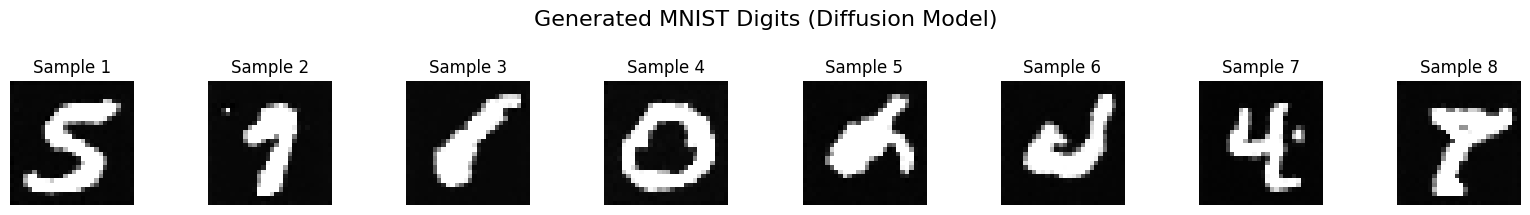

Generation complete!


In [10]:
# =====================================================
# SAMPLING: Generate new images from noise
# =====================================================

@torch.no_grad()  # Disable gradient computation (saves memory, faster inference)
def sample_and_plot(model, num_images=8):
    """
    Generate new images by reversing the diffusion process.

    Theory: Start with pure Gaussian noise and iteratively denoise using the trained U-Net.
    At each step t, we:
        1. Predict the noise in the current image
        2. Remove the predicted noise (denoise)
        3. Add small stochastic noise (if t > 0, for diversity)

    This is the reverse of the forward diffusion process we used during training.

    Parameters:
        model: Trained DiffusionUNet model
        num_images: Number of images to generate (default: 8)

    Returns:
        Generated images as PyTorch tensor
    """

    print(f"\nGenerating {num_images} new images from pure noise...")

    # Set model to evaluation mode
    # Disables dropout, batch norm updates, etc.
    model.eval()

    # === STEP 1: START WITH PURE RANDOM NOISE ===
    # This is x_T, the starting point of the reverse process
    # Shape: [num_images, 1, 28, 28] (batch of grayscale images)
    # randn samples from standard normal distribution N(0, 1)
    img = torch.randn((num_images, 1, 28, 28), device=device)
    # At this point, img is completely random noise with no structure

    # === STEP 2: ITERATIVE DENOISING ===
    # Gradually remove noise over T timesteps
    # We go backwards: T-1 -> T-2 -> ... -> 1 -> 0
    # Theory: Each step removes a small amount of noise, gradually revealing the image
    for i in reversed(range(T)):  # i goes from 299 to 0

        # Create timestep tensor for this iteration
        # All images in batch are at the same timestep
        # full() creates tensor filled with value i
        t = torch.full((num_images,), i, device=device, dtype=torch.long)
        # t shape: [num_images], all values are i

        # === PREDICT NOISE ===
        # Ask the U-Net: "What noise is present in this image at timestep t?"
        # The model has learned during training to answer this question
        pred_noise = model(img, t)
        # pred_noise shape: [num_images, 1, 28, 28]

        # === EXTRACT CONSTANTS FOR THIS TIMESTEP ===
        # Get the precomputed diffusion constants for timestep i
        alpha = alphas[i]  # alpha_t: signal retention coefficient
        alpha_cumprod = alphas_cumprod[i]  # alpha_bar_t: cumulative signal retention
        beta = betas[i]  # beta_t: noise variance

        # === ADD STOCHASTIC NOISE (for diversity) ===
        # Add random noise at all steps except the last (t=0)
        # Theory: Adding noise maintains diversity in generation
        # At t=0 (final step), we want deterministic output, so no noise
        if i > 0:
            noise = torch.randn_like(img)  # Sample N(0, I)
        else:
            noise = torch.zeros_like(img)  # No noise at final step

        # === REVERSE DDPM STEP ===
        # Apply the reverse diffusion formula to denoise
        # Formula: x_{t-1} = (1/sqrt(alpha_t)) * (x_t - ((1-alpha_t)/sqrt(1-alpha_bar_t)) * epsilon_hat) + sqrt(beta_t) * z
        #
        # Breaking it down:
        # 1. (1-alpha) / sqrt(1-alpha_cumprod): Scale factor for predicted noise
        # 2. img - (scale * pred_noise): Remove predicted noise from current image
        # 3. (1 / sqrt(alpha)) * (...): Rescale to account for signal retention
        # 4. + sqrt(beta) * noise: Add small stochastic noise (except at t=0)

        img = (1 / torch.sqrt(alpha)) * \
              (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * pred_noise) + \
              torch.sqrt(beta) * noise

        # After this step, img is less noisy (one step closer to clean image)
        # Progress: x_t -> x_{t-1}

        # Optional: Print progress every 50 steps
        if (i + 1) % 50 == 0 or i == 0:
            print(f"  Denoising step: {T-i}/{T} (timestep {i})")

    # === STEP 3: POST-PROCESS AND VISUALIZE ===
    # After T iterations, img should contain clean generated images
    # img is in range [-1, 1], need to convert for visualization

    # Move to CPU and remove batch/channel dimensions for plotting
    img_cpu = img.cpu()

    # Clip to ensure values are in [-1, 1] (sometimes model outputs slightly outside)
    img_cpu = torch.clamp(img_cpu, -1, 1)

    # Denormalize from [-1, 1] to [0, 1] for visualization
    # Formula: (x + 1) / 2
    img_cpu = (img_cpu + 1) / 2

    # Plot generated images in a grid
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for idx in range(num_images):
        axes[idx].imshow(img_cpu[idx].squeeze(), cmap='gray')
        axes[idx].axis('off')
        axes[idx].set_title(f"Sample {idx+1}")

    plt.suptitle("Generated MNIST Digits (Diffusion Model)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

    print("Generation complete!")

    return img_cpu

# Generate and display images
generated_images = sample_and_plot(model, num_images=8)

## Explanation of results:

Sample 1 is what the model "found" when it started with one specific block of noise.

Sample 4 is what it found starting with a different block of noise.

The fact that they look like real digits (like the "5" in Sample 1 or the "0" in Sample 4) proves the model has learned the "rules" of what a handwritten number looks like.

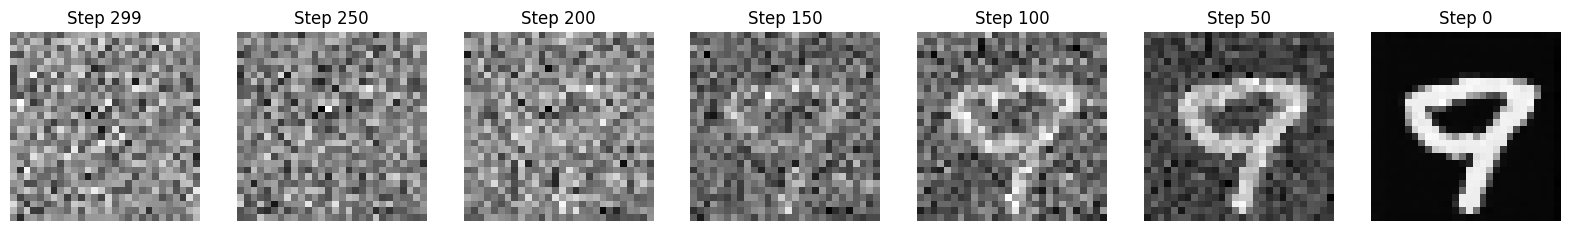

In [ ]:
@torch.no_grad()
def visualize_diffusion_steps(model, num_steps=300):
    model.eval()
    # 1. Start with pure random noise
    img = torch.randn((1, 1, 28, 28), device=device)

    # List to store snapshots
    snapshots = []
    # Define which steps we want to "see" (e.g., every 50 steps)
    record_at = [299, 250, 200, 150, 100, 50, 0]

    for i in reversed(range(num_steps)):
        t = torch.full((1,), i, device=device, dtype=torch.long)

        # Predict noise
        pred_noise = model(img, t)

        # Reverse Step math (same as your current loop)
        alpha = alphas[i]
        alpha_cumprod = alphas_cumprod[i]
        beta = betas[i]

        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = 0

        img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * pred_noise) + torch.sqrt(beta) * noise

        # 2. Capture the snapshot if it's a milestone step
        if i in record_at:
            # Scale back to [0, 1] for plotting
            snapshot = (img.detach().cpu().squeeze() + 1) / 2
            snapshots.append((i, snapshot))

    # 3. Plot the results in a row
    fig, axes = plt.subplots(1, len(snapshots), figsize=(20, 4))
    for idx, (t_val, snap) in enumerate(snapshots):
        axes[idx].imshow(snap, cmap='gray')
        axes[idx].set_title(f"Step {t_val}")
        axes[idx].axis('off')
    plt.show()

# Run this to see the process
visualize_diffusion_steps(model)

## Explanation of Results:

### How the Model Generates Images:

The DDPM works by starting with pure random noise and gradually cleaning it up over 300 steps. Here's what happens:

**Early Steps (Steps 300 → 200):** The model looks at the noisy image and asks "what noise is here?" It removes a tiny bit of noise, but the image is still mostly chaos. The U-Net uses time embeddings to know what step it's at, so it knows how much noise to expect.

**Middle Steps (Steps 200 → 100):** Larger structures start to emerge. The model's bottleneck layer (the most compressed part) begins to recognize high-level patterns. You might see faint shapes forming, like the basic outline of a digit becoming visible through the static.

**Final Steps (Steps 100 → 0):** The model refines the details. The skip connections help bring sharp details from the earlier layers, cleaning up edges and removing the last bits of noise. The background becomes clear, and the digit becomes sharp and recognizable.


## What We Learned - How Diffusion Models Think:

### The Big Picture:

Diffusion models work backwards from noise to create new images. Think of it like developing a photograph in reverse:

1. **Phase 1 - Chaos to Shapes (Steps 300-150):**
   - We start with completely random static (like TV noise)
   - The model looks at each step and asks: "What patterns do I recognize here?"
   - Slowly, broad shapes emerge - but they're still very blurry
   - The model uses the timestep information (time embeddings) to know how much cleanup to do at each step

2. **Phase 2 - Shapes to Details (Steps 150-50):**
   - The middle layers of the U-Net have processed so much information (through the bottleneck) that they've captured the "essence" of a digit
   - Specific digit features start becoming clear (curves, straight lines, loops)
   - The model knows roughly what digit is forming, but edges are still fuzzy

3. **Phase 3 - Details to Perfection (Steps 50-0):**
   - Skip connections carry detailed information straight from the encoder to decoder
   - These high-resolution details sharpen edges and clean up the background
   - The final steps remove the last traces of noise, producing a crisp, recognizable digit

### Why This Matters:

The fact that we get **different, realistic-looking digits every time** (not just variations of memorized training images) proves that the model learned something deeper. It learned the **statistical patterns** of what makes a handwritten digit look natural. This is why diffusion models are so powerful—they understand data distributions, not just individual examples.


## Optional: Additional Experiments & Extensions

Now that you have a working DDPM, here are some ways to extend and improve it:

### 1. **Save and Load the Model**
```python
# Save trained model
torch.save(model.state_dict(), 'ddpm_mnist.pth')

# Load model later
model = DiffusionUNet().to(device)
model.load_state_dict(torch.load('ddpm_mnist.pth'))
```

### 2. **Visualize the Diffusion Process**
Create an animation showing how noise is added/removed:
```python
# Generate images at intermediate timesteps
timesteps_to_show = [0, 50, 100, 150, 200, 250, 299]
```

### 3. **Conditional Generation**
Extend the model to generate specific digits:
- Add class label embedding to the U-Net
- Concatenate with time embedding
- Train with labels, sample with desired class

### 4. **Experiment with Hyperparameters**
- **T**: Try 100, 500, 1000 timesteps (trade-off: quality vs speed)
- **beta schedule**: Cosine schedule instead of linear
- **Architecture**: More layers, different channel sizes
- **Learning rate**: Adjust for faster/slower convergence

### 5. **Evaluation Metrics**
- **FID Score**: Measure quality vs real MNIST
- **Inception Score**: Measure diversity and quality
- **Visual inspection**: Do generated digits look realistic?

### 6. **Speed Up Sampling**
- **DDIM**: Deterministic sampling (fewer steps, faster)
- **Skip timesteps**: Sample every k steps instead of every step

### 7. **Apply to Other Datasets**
- Fashion-MNIST (clothing items)
- CIFAR-10 (colored images)
- CelebA (faces)

In [11]:
# =====================================================
# OPTIONAL: Save the trained model
# =====================================================

# Save model weights to disk
# This allows you to load the model later without retraining
model_save_path = 'ddpm_mnist_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),  # Model weights
    'optimizer_state_dict': optimizer.state_dict(),  # Optimizer state
    'epoch': EPOCHS,  # Number of epochs trained
    'T': T,  # Timesteps (important for loading)
}, model_save_path)

print(f"Model saved to: {model_save_path}")
print("   To load later:")
print("   checkpoint = torch.load('ddpm_mnist_model.pth')")
print("   model.load_state_dict(checkpoint['model_state_dict'])")

Model saved to: ddpm_mnist_model.pth
   To load later:
   checkpoint = torch.load('ddpm_mnist_model.pth')
   model.load_state_dict(checkpoint['model_state_dict'])
